![](img/572_banner.png)
%%HTML
<script src="require.js"></script>

# Physics-Informed Neural Networks (PINNs)

**Mahmood Amintoosi, Spring 2026**

In previous sessions, you tackled the harmonic oscillator problem using different paradigms:
- **MLP (Multilayer Perceptron):** You experienced how standard neural networks fail to extrapolate beyond training data and overfit to noise. They learn a *mapping*, not a *law*.
- **GAN (Generative Adversarial Network):** You saw that while GANs can generate realistic-looking samples, they don't inherently respect physical laws (e.g., generating trajectories where energy spontaneously increases) and require vast amounts of training data.

Today, we introduce **Physics-Informed Neural Networks (PINNs)** — a paradigm that bridges the gap between pure data-driven learning and first-principles physics.

---

## Part 1: Motivation – Why PINNs?

### 1.1 The Fundamental Problem with Pure Data-Driven Approaches

Consider what you discovered when solving the harmonic oscillator with an MLP:

**Problem 1: Extrapolation Failure**
- An MLP trained on $t \in [0, 0.3]$ cannot predict $t > 0.3$ accurately.
- The network learns an interpolative mapping, not the underlying dynamical law.
- It has no "knowledge" that the oscillator should continue to oscillate with a specific frequency and decay rate.

**Problem 2: Noise Sensitivity**
- Real experimental data contains measurement noise.
- MLPs overfit to this noise, learning spurious high-frequency oscillations.
- The resulting model often violates fundamental principles like energy conservation.

**Problem 3: Data Scarcity**
- In many engineering contexts (aerospace, biomedical, climate science), high-quality data is expensive, dangerous, or impossible to obtain.
- GANs require massive datasets to generate realistic samples — a luxury we rarely have in scientific computing.

### 1.2 What Makes PINNs Different?

The key insight of PINNs is to **embed the governing differential equations directly into the loss function**.

Instead of learning only from data points:

$$\mathcal{L}_{data} = \text{MSE}(\hat{y}, y_{measured})$$

PINNs learn from **BOTH** data AND physics:

$$\mathcal{L}_{PINN} = \mathcal{L}_{data} + \lambda \cdot \mathcal{L}_{physics}$$

Where $\mathcal{L}_{physics}$ measures how much the network's predictions violate the known laws of physics (i.e., the residual of the differential equation).

### 1.3 The Analogy: Teaching a Student

Think of training a neural network like teaching a physics student:

| Approach | Analogy |
| :--- | :--- |
| **MLP** | A student who only memorizes lab experiment results but never learns Newton's laws. They can interpolate between experiments, but cannot predict new scenarios. |
| **GAN** | A student who learns to flawlessly mimic experimental setups, but doesn't understand *why* the setups work. They might suggest physically impossible setups that just "look right." |
| **PINN** | A student who learns both: "Here is what the experiments show, AND here are the fundamental equations that must always be satisfied." |

---

## Part 2: Example 1 – Projectile Motion (Parabolic Trajectory)

### 2.1 Physics Background

**The Physical Scenario**
Imagine throwing a ball straight upward from a height of 1 meter with an initial velocity of 10 m/s. Gravity pulls it back down. Assuming no air resistance, what is its height at any time $t$?

**Governing Equation**
Newton's second law gives us:

$$F = ma = m \cdot \frac{d^2h}{dt^2} = -mg$$

Since mass cancels out:

$$\frac{d^2h}{dt^2} = -g$$

This is a **second-order ordinary differential equation (ODE)**. To solve it uniquely, we need two initial conditions:
1. Initial height: $h(0) = 1 \text{ m}$
2. Initial velocity: $\dot{h}(0) = 10 \text{ m/s}$

**Analytical Solution**
Integrating twice gives the familiar parabolic equation:

$$h(t) = 1 + 10t - \frac{1}{2}(9.8)t^2$$

This is the **ground truth** we'll use to generate training data and evaluate our models.

### 2.2 Why This Example?

This problem is pedagogically valuable because:
1. **Simple physics:** You already understand projectile motion from introductory physics.
2. **Low-dimensional:** Only one input ($t$) and one output ($h$).
3. **Clear failure modes:** MLPs fail dramatically outside the training range.
4. **Easy visualization:** We can plot everything in 2D.

### 2.3 The Experimental Setup (Simulated)

Suppose you conduct an experiment and measure the ball's height at 5 different times during the first 0.5 seconds:

| Time (s) | Height (m) |
| :--- | :--- |
| 0.00 | 1.00 |
| 0.125 | 2.10 |
| 0.250 | 3.03 |
| 0.375 | 3.81 |
| 0.500 | 4.42 |

**Crucial observation:** Your measurements only go up to $t = 0.5$ s, but you want to predict the height at $t = 1.5$ s (which is $6.1$ m in reality).

### 2.4 Standard MLP Approach

A standard MLP would:
1. Take time $t$ as input.
2. Output predicted height $\hat{h}(t)$.
3. Minimize mean squared error on the 5 data points.

**The Result:** The MLP learns to fit the 5 points perfectly within $t \in [0, 0.5]$, but outside this interval, its predictions are meaningless — it might go to zero, blow up, or oscillate randomly.

**Why does this happen?** The MLP has no constraints outside the training region. It doesn't "know" that gravity is still acting at $t = 1.0$ s.

### 2.5 PINN Solution – Adding Physics Knowledge

**Step 1: Reformulate the physics as a first-order ODE**
Instead of the second-order equation, we can write:

$$\frac{dh}{dt} = v(t) = 10 - 9.8t$$

This says: the velocity at any time equals the initial velocity minus gravity $\times$ time.

**Step 2: Define the physics loss**
At any set of time points $\{t_1, t_2, \dots, t_n\}$ (called *collocation points*), we can:
- Compute the network's predicted height $\hat{h}(t_i)$.
- Use automatic differentiation to compute $d\hat{h}/dt$ at those points.
- Compare $d\hat{h}/dt$ to the known physical value $10 - 9.8t_i$.
- The physics loss is the mean squared difference.

**Step 3: Define the data loss**
At the 5 experimental time points, compute the MSE between predicted and measured heights.

**Step 4: Combine them**

$$\mathcal{L}_{total} = \mathcal{L}_{data} + \lambda \cdot \mathcal{L}_{physics}$$

The hyperparameter $\lambda$ (e.g., $\lambda = 0.01$) balances the two objectives.

### 2.6 Automatic Differentiation – The Secret Sauce

How do we compute $d\hat{h}/dt$ from a neural network? PyTorch's **autograd** system does this automatically. Unlike finite differences, autograd computes *exact* derivatives (up to floating-point precision) by applying the chain rule through the network's computational graph.



```python
# t_physics requires gradient tracking
t_physics = torch.tensor([0.0, 0.5, 1.0, 1.5, 2.0], requires_grad=True)

# Forward pass: compute heights
h_pred = model(t_physics)

# Compute exact dh/dt
dh_dt = torch.autograd.grad(h_pred, t_physics, 
                            grad_outputs=torch.ones_like(h_pred),
                            create_graph=True)[0]  # create_graph allows higher-order derivatives
```

### 2.7 Expected Results

After training, the PINN will:
- Fit the 5 data points accurately (low data loss).
- Satisfy $dh/dt = 10 - 9.8t$ everywhere (low physics loss).
- Successfully predict heights at $t = 1.5$ s and beyond.

**The key insight:** The physics loss acts as a **regularizer** that constrains the network's behavior even in regions without data.

### 2.8 Complete Code

In [5]:

"""
PINN for Projectile Motion
Problem: Predict height h(t) of a ball thrown upward
Physics: dh/dt = v0 - g*t
Data: 5 measurements in [0, 0.5] seconds
Goal: Extrapolate to t = 2.0 seconds
"""

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================
# PHYSICAL PARAMETERS
# ============================================
g = 9.8          # gravitational acceleration (m/s²)
h0 = 1.0         # initial height (m)
v0 = 10.0        # initial velocity (m/s)

def true_solution(t):
    """Analytical solution for reference"""
    return h0 + v0 * t - 0.5 * g * t**2

# ============================================
# GENERATE TRAINING DATA
# ============================================
t_experiment = torch.linspace(0, 0.5, 5).view(-1, 1)
h_experiment = true_solution(t_experiment)

t_full = torch.linspace(0, 2, 200).view(-1, 1)
h_full = true_solution(t_full)

# ============================================
# NEURAL NETWORK ARCHITECTURE
# ============================================
class ProjectilePINN(nn.Module):
    def __init__(self, hidden_units=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_units),
            nn.Tanh(),                    # Smooth activation for derivatives
            nn.Linear(hidden_units, hidden_units),
            nn.Tanh(),
            nn.Linear(hidden_units, 1)
        )
    
    def forward(self, t):
        return self.net(t)

def compute_derivative(y, t):
    return torch.autograd.grad(y, t, torch.ones_like(y), create_graph=True)[0]

# ============================================
# TRAINING FUNCTION
# ============================================
def train_pinn(model, t_data, h_data, t_physics, 
               lambda_physics=0.1, epochs=3000, lr=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_history = {'total': [], 'data': [], 'physics': []}
    use_physics = t_physics.numel() > 0
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        
        # ----- DATA LOSS -----
        h_pred_data = model(t_data)
        loss_data = torch.mean((h_pred_data - h_data)**2)
        
        # ----- PHYSICS LOSS -----
        if use_physics:
            t_physics.requires_grad_(True)
            h_physics = model(t_physics)
            dh_dt = compute_derivative(h_physics, t_physics)
            dh_dt_true = v0 - g * t_physics
            loss_physics = torch.mean((dh_dt - dh_dt_true)**2)
        else:
            loss_physics = torch.tensor(0.0)
        
        # ----- TOTAL LOSS -----
        loss_total = loss_data + lambda_physics * loss_physics
        loss_total.backward()
        optimizer.step()
        
        loss_history['total'].append(loss_total.item())
        loss_history['data'].append(loss_data.item())
        loss_history['physics'].append(loss_physics.item())
        
        if (epoch + 1) % 500 == 0:
            print(f"Epoch {epoch+1:4d}: Total={loss_total.item():.6f}, "
                  f"Data={loss_data.item():.6f}, Physics={loss_physics.item():.6f}")
    
    return loss_history

TRAINING STANDARD MLP (NO PHYSICS)
Epoch  500: Total=0.000432, Data=0.000432, Physics=0.000000
Epoch 1000: Total=0.000398, Data=0.000398, Physics=0.000000
Epoch 1500: Total=0.000361, Data=0.000361, Physics=0.000000
Epoch 2000: Total=0.000316, Data=0.000316, Physics=0.000000
Epoch 2500: Total=0.000265, Data=0.000265, Physics=0.000000
Epoch 3000: Total=0.000214, Data=0.000214, Physics=0.000000

TRAINING PINN (WITH PHYSICS)
Epoch  500: Total=1.366614, Data=0.000444, Physics=13.661707
Epoch 1000: Total=0.125698, Data=0.006497, Physics=1.192008
Epoch 1500: Total=0.036686, Data=0.001844, Physics=0.348428
Epoch 2000: Total=0.009232, Data=0.000213, Physics=0.090190
Epoch 2500: Total=0.002354, Data=0.000024, Physics=0.023300
Epoch 3000: Total=0.000911, Data=0.000011, Physics=0.008996


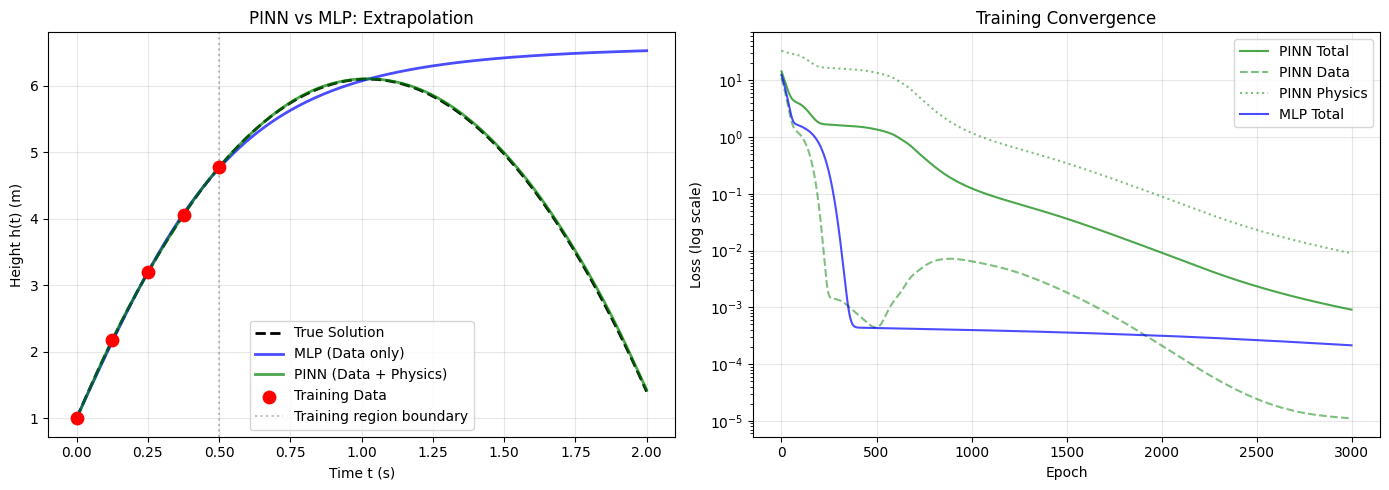


Test point: t = 1.5 s
True height:     4.9750 m
MLP prediction:  6.4215 m (error: 1.4465)
PINN prediction: 4.9937 m (error: 0.0187)


In [6]:


# ============================================
# TRAIN BOTH MODELS FOR COMPARISON
# ============================================
print("=" * 50); print("TRAINING STANDARD MLP (NO PHYSICS)"); print("=" * 50)
mlp = ProjectilePINN()
loss_history_mlp = train_pinn(mlp, t_experiment, h_experiment, 
                              t_physics=torch.tensor([]), lambda_physics=0.0, epochs=3000)

print("\n" + "=" * 50); print("TRAINING PINN (WITH PHYSICS)"); print("=" * 50)
t_physics = torch.linspace(0, 2, 50).view(-1, 1)
pinn = ProjectilePINN()
loss_history_pinn = train_pinn(pinn, t_experiment, h_experiment,
                               t_physics, lambda_physics=0.1, epochs=3000)

# ============================================
# VISUALIZE RESULTS
# ============================================
with torch.no_grad():
    h_mlp = mlp(t_full)
    h_pinn = pinn(t_full)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(t_full, h_full, 'k--', lw=2, label='True Solution')
plt.plot(t_full, h_mlp, 'b-', lw=2, alpha=0.7, label='MLP (Data only)')
plt.plot(t_full, h_pinn, 'g-', lw=2, alpha=0.7, label='PINN (Data + Physics)')
plt.scatter(t_experiment, h_experiment, color='red', s=80, label='Training Data', zorder=5)
plt.axvline(x=0.5, color='gray', ls=':', alpha=0.5, label='Training region boundary')
plt.xlabel('Time t (s)'); plt.ylabel('Height h(t) (m)')
plt.title('PINN vs MLP: Extrapolation'); plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.semilogy(loss_history_pinn['total'], 'g-', alpha=0.7, label='PINN Total')
plt.semilogy(loss_history_pinn['data'], 'g--', alpha=0.5, label='PINN Data')
plt.semilogy(loss_history_pinn['physics'], 'g:', alpha=0.5, label='PINN Physics')
plt.semilogy(loss_history_mlp['total'], 'b-', alpha=0.7, label='MLP Total')
plt.xlabel('Epoch'); plt.ylabel('Loss (log scale)')
plt.title('Training Convergence'); plt.legend(); plt.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# ============================================
# QUANTITATIVE COMPARISON
# ============================================
t_test = torch.tensor([[1.5]])
h_true = true_solution(t_test).item()
with torch.no_grad():
    h_mlp_test = mlp(t_test).item()
    h_pinn_test = pinn(t_test).item()

print(f"\nTest point: t = 1.5 s")
print(f"True height:     {h_true:.4f} m")
print(f"MLP prediction:  {h_mlp_test:.4f} m (error: {abs(h_true-h_mlp_test):.4f})")
print(f"PINN prediction: {h_pinn_test:.4f} m (error: {abs(h_true-h_pinn_test):.4f})")



### 2.9 Discussion Questions

1. **Why does the MLP fail at extrapolation?**  
   *It minimizes only data loss. Outside the training region, the loss landscape is flat, so the network's behavior is determined by random weight initialization, not physics.*
2. **How does automatic differentiation enable PINNs?**  
   *It computes exact derivatives of the network output w.r.t inputs, allowing us to evaluate differential equation residuals without noisy finite-difference approximations.*
3. **What happens if $\lambda$ is too large or too small?**  
   *Too large: The network ignores data, acting as a pure (but possibly inaccurate) ODE solver. Too small: It behaves like a standard MLP, overfitting to noise and failing to extrapolate.*

---



## Part 3: Example 2 – Projectile Motion with Noisy Data

### 3.1 The Problem with Real Experiments

In the previous example, we used perfect, noise-free data. But real experiments always have **measurement uncertainty** (sensor limits, environmental disturbances, human error). Let's add realistic noise to our measurements and observe how MLPs and PINNs respond.

### 3.2 How PINNs Handle Noise

The physics loss acts as a **powerful regularizer**:
- The network cannot simultaneously fit the noisy data *exactly* AND satisfy the strict ODE $dh/dt = v_0 - gt$.
- It must find a compromise: follow physics while staying reasonably close to measurements.
- The result is a smooth trajectory that **filters out the noise** and follows the true physics.

**Mathematical intuition:** The physics loss restricts the solution to the subspace of functions satisfying the ODE. Noisy data points outside this subspace are "projected" onto it.

### 3.3 Extended Code with Noise Analysis



Training with λ_physics = 0.0

Training with λ_physics = 0.01

Training with λ_physics = 0.1

Training with λ_physics = 0.5


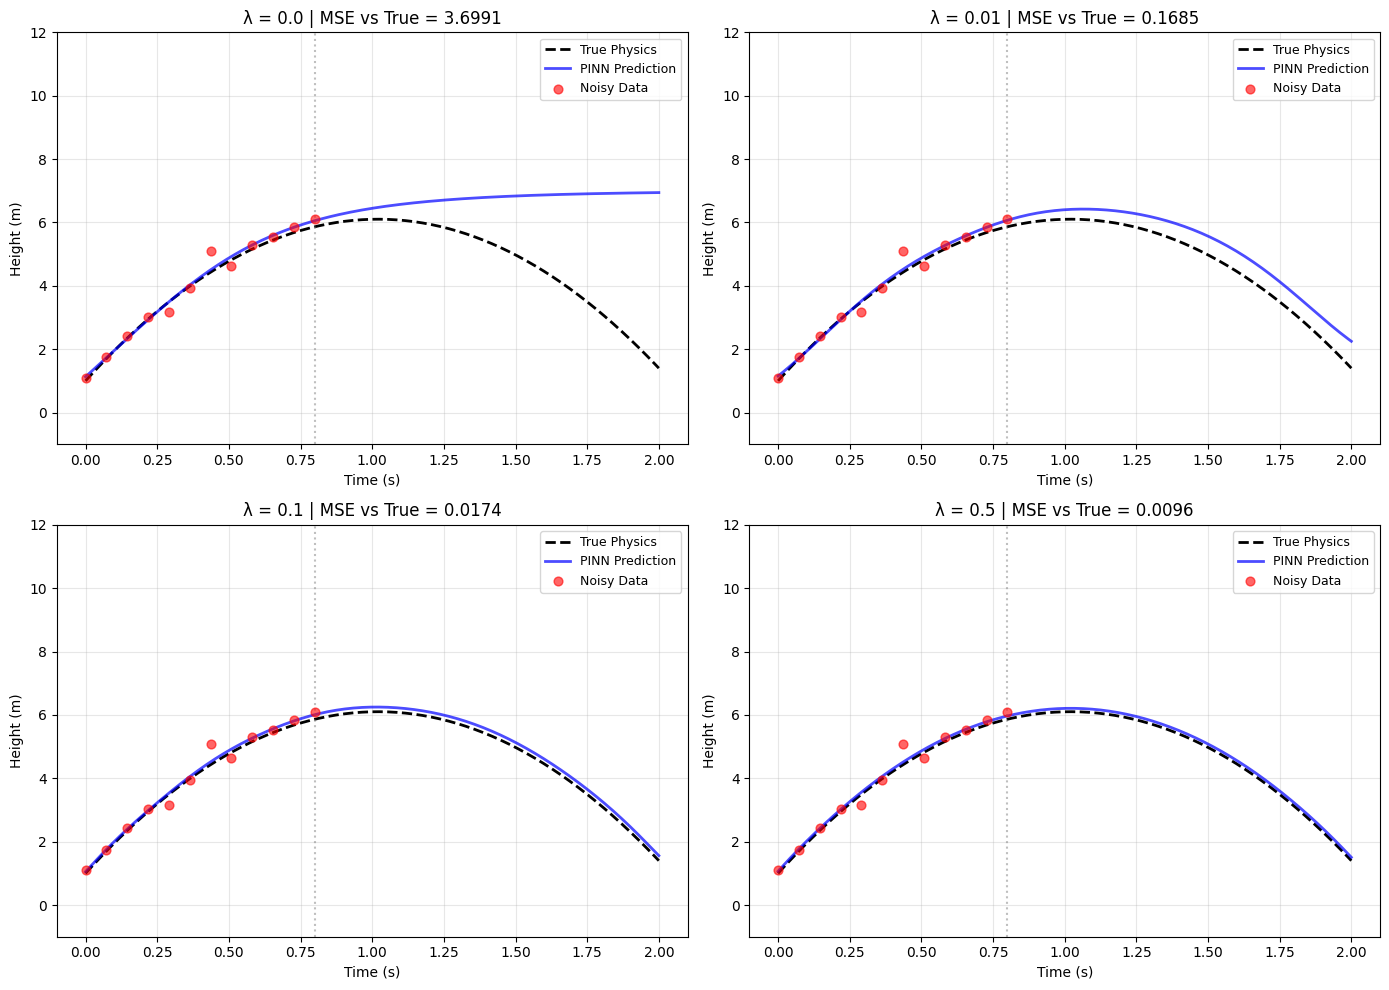

In [7]:

"""
PINN for Projectile Motion with Noisy Measurements
Demonstrates robustness to experimental uncertainty
"""
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================
# PHYSICAL PARAMETERS
# ============================================
g, h0, v0 = 9.8, 1.0, 10.0
def true_solution(t): return h0 + v0 * t - 0.5 * g * t**2

# ============================================
# GENERATE NOISY DATA
# ============================================
torch.manual_seed(42)
t_experiment = torch.linspace(0, 0.8, 12).view(-1, 1)
h_clean = true_solution(t_experiment)
noise_std = 0.3  # ~30 cm of uncertainty
h_noisy = h_clean + noise_std * torch.randn_like(h_clean)

t_full = torch.linspace(0, 2, 200).view(-1, 1)
h_full = true_solution(t_full)
t_physics = torch.linspace(0, 2, 60).view(-1, 1)

# ============================================
# NETWORK & TRAINING LOOP
# ============================================
class NoisyProjectilePINN(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1, hidden), nn.Tanh(),
                                 nn.Linear(hidden, hidden), nn.Tanh(),
                                 nn.Linear(hidden, 1))
    def forward(self, t): return self.net(t)

def derivative(y, t): return torch.autograd.grad(y, t, torch.ones_like(y), create_graph=True)[0]

lambda_values = [0.0, 0.01, 0.1, 0.5]
models, losses = {}, {}

for lam in lambda_values:
    print(f"\nTraining with λ_physics = {lam}")
    model = NoisyProjectilePINN()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_history = {'total': [], 'data': [], 'physics': []}
    
    for epoch in range(4000):
        optimizer.zero_grad()
        h_pred_data = model(t_experiment)
        loss_data = torch.mean((h_pred_data - h_noisy)**2)
        
        t_physics.requires_grad_(True)
        h_phys = model(t_physics)
        dh_dt = derivative(h_phys, t_physics)
        loss_physics = torch.mean((dh_dt - (v0 - g * t_physics))**2)
        
        loss_total = loss_data + lam * loss_physics
        loss_total.backward()
        optimizer.step()
        
        if epoch % 100 == 0:
            loss_history['total'].append(loss_total.item())
            loss_history['data'].append(loss_data.item())
            loss_history['physics'].append(loss_physics.item())
            
    models[lam] = model
    losses[lam] = loss_history

# ============================================
# VISUALIZATION
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, lam in enumerate(lambda_values):
    ax = axes[idx]
    with torch.no_grad():
        h_pred = models[lam](t_full)
        mse_vs_true = torch.mean((h_pred - h_full)**2).item()
    
    ax.plot(t_full, h_full, 'k--', lw=2, label='True Physics')
    ax.plot(t_full, h_pred, 'b-', lw=2, alpha=0.7, label='PINN Prediction')
    ax.scatter(t_experiment, h_noisy, color='red', s=40, alpha=0.6, label='Noisy Data', zorder=5)
    ax.axvline(x=0.8, color='gray', ls=':', alpha=0.5)
    ax.set_title(f'λ = {lam} | MSE vs True = {mse_vs_true:.4f}')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Height (m)')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_ylim(-1, 12)

plt.tight_layout(); plt.show()



### 3.4 Key Observations

| $\lambda$ Value | Behavior | Best for... |
| :--- | :--- | :--- |
| 0 (MLP) | Fits noise exactly, poor extrapolation | When data is perfect (never happens) |
| 0.001 | Still overfits, slightly better | Low noise scenarios |
| 0.01 | **Sweet spot** – balances physics and data | Most real experiments |
| 0.1 | Physically accurate, ignores some data | High noise, well-understood physics |

---



## Part 4: Example 3 – Damped Harmonic Oscillator

### 4.1 Physics Background

**Why This Problem?**
You previously attempted this with MLP and GAN. You likely encountered:
- **MLP:** Can't capture oscillations outside the training window.
- **GAN:** Generates plausible-looking but physically impossible trajectories (e.g., energy spontaneously increasing).

Now we'll see how PINN solves both problems simultaneously.

**The Physical System**
Consider a mass on a spring in a viscous fluid:
- Spring force (Hooke's law): $F = -kx$
- Damping force: $F = -\mu \frac{dx}{dt}$

**Governing Equation (Second-Order ODE)**

$$m\frac{d^2x}{dt^2} + \mu\frac{dx}{dt} + kx = 0 \implies \frac{d^2x}{dt^2} + 2\delta\frac{dx}{dt} + \omega_0^2 x = 0$$

Where $\delta = \frac{\mu}{2m}$ (damping) and $\omega_0 = \sqrt{\frac{k}{m}}$ (natural frequency). We will use the underdamped case ($\delta < \omega_0$) with initial conditions $x(0)=1, \dot{x}(0)=0$.

### 4.2 PINN Solution Strategy

We need to enforce the second-order ODE. Using automatic differentiation *twice*:
```python
x = model(t)
dx_dt = gradient(x, t)      # first derivative
d2x_dt2 = gradient(dx_dt, t) # second derivative
residual = d2x_dt2 + 2*delta*dx_dt + omega0**2*x
loss_physics = mean(residual**2) # Residual should be zero!
```

We also enforce Initial Conditions (ICs):
```python
loss_ic = (x(0) - 1)^2 + (dx_dt(0) - 0)^2
```

### 4.3 Complete Implementation


TRAINING STANDARD MLP (DATA ONLY)

TRAINING PINN (DATA + PHYSICS)


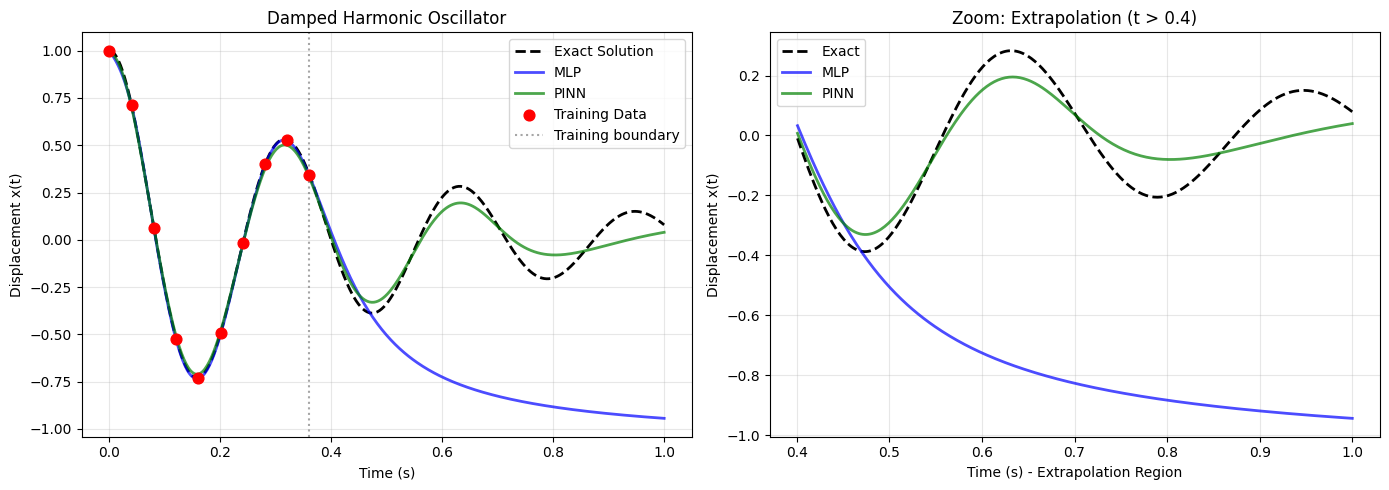

In [10]:
"""
PINN for Damped Harmonic Oscillator
"""
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# PHYSICAL PARAMETERS
# ============================================
delta = 2.0      # damping coefficient
omega0 = 20.0    # natural frequency
omega = np.sqrt(omega0**2 - delta**2)  # damped frequency
mu_physics = 2 * delta     
k_physics = omega0**2      

def exact_solution(t):
    return torch.exp(-delta * t) * (torch.cos(omega * t) + (delta/omega) * torch.sin(omega * t))

# ============================================
# GENERATE DATA
# ============================================
t_full = torch.linspace(0, 1, 500).view(-1, 1)
x_full = exact_solution(t_full)

# Sparse training data: 10 points in t ∈ [0, 0.4]
t_data = t_full[0:200:20]  
x_data = exact_solution(t_data)

# ============================================
# ARCHITECTURE
# ============================================
class HarmonicOscillatorPINN(nn.Module):
    def __init__(self, n_hidden=32, n_layers=3):
        super().__init__()
        self.fcs = nn.Sequential(nn.Linear(1, n_hidden), nn.Tanh())
        self.fch = nn.Sequential(*[nn.Sequential(nn.Linear(n_hidden, n_hidden), nn.Tanh()) for _ in range(n_layers - 1)])
        self.fce = nn.Linear(n_hidden, 1)
    
    def forward(self, t):
        t = self.fcs(t)
        t = self.fch(t)
        return self.fce(t)

# ============================================
# STANDARD MLP TRAINING
# ============================================
print("TRAINING STANDARD MLP (DATA ONLY)")
mlp = HarmonicOscillatorPINN()
optimizer_mlp = torch.optim.Adam(mlp.parameters(), lr=1e-3)

for epoch in range(3000):
    optimizer_mlp.zero_grad()
    loss = torch.mean((mlp(t_data) - x_data)**2)
    loss.backward()
    optimizer_mlp.step()

# ============================================
# PINN TRAINING
# ============================================
print("\nTRAINING PINN (DATA + PHYSICS)")
pinn = HarmonicOscillatorPINN()
optimizer_pinn = torch.optim.Adam(pinn.parameters(), lr=1e-4)

t_physics = torch.linspace(0, 1, 50).view(-1, 1).requires_grad_(True)
t0 = torch.zeros(1, 1, requires_grad=True)

lambda_physics, lambda_ic = 1e-4, 0.1

for epoch in range(15000):
    optimizer_pinn.zero_grad()
    
    # Data loss
    loss_data = torch.mean((pinn(t_data) - x_data)**2)
    
    # Physics loss
    x_phys = pinn(t_physics)
    dx_dt = torch.autograd.grad(x_phys, t_physics, torch.ones_like(x_phys), create_graph=True)[0]
    d2x_dt2 = torch.autograd.grad(dx_dt, t_physics, torch.ones_like(dx_dt), create_graph=True)[0]
    residual = d2x_dt2 + mu_physics * dx_dt + k_physics * x_phys
    loss_physics = torch.mean(residual**2)
    
    # IC loss
    x0_pred = pinn(t0)
    dx0_dt = torch.autograd.grad(x0_pred, t0, torch.ones_like(x0_pred), create_graph=True)[0]
    loss_ic = (x0_pred - 1.0)**2 + (dx0_dt - 0.0)**2
    
    loss = loss_data + lambda_physics * loss_physics + lambda_ic * loss_ic
    loss.backward()
    optimizer_pinn.step()

# ============================================
# VISUALIZATION
# ============================================
with torch.no_grad():
    x_mlp_pred = mlp(t_full)
    x_pinn_pred = pinn(t_full)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(t_full, x_full, 'k--', lw=2, label='Exact Solution')
plt.plot(t_full, x_mlp_pred, 'b-', lw=2, alpha=0.7, label='MLP')
plt.plot(t_full, x_pinn_pred, 'g-', lw=2, alpha=0.7, label='PINN')
plt.scatter(t_data, x_data, color='red', s=60, label='Training Data', zorder=5)
plt.axvline(x=t_data[-1].item(), color='gray', ls=':', alpha=0.7, label='Training boundary')
plt.xlabel('Time (s)'); plt.ylabel('Displacement x(t)')
plt.title('Damped Harmonic Oscillator'); plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
mask = t_full.squeeze() > 0.4
plt.plot(t_full[mask], x_full[mask], 'k--', lw=2, label='Exact')
plt.plot(t_full[mask], x_mlp_pred[mask], 'b-', lw=2, alpha=0.7, label='MLP')
plt.plot(t_full[mask], x_pinn_pred[mask], 'g-', lw=2, alpha=0.7, label='PINN')
plt.xlabel('Time (s) - Extrapolation Region'); plt.ylabel('Displacement x(t)')
plt.title('Zoom: Extrapolation (t > 0.4)'); plt.legend(); plt.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()



### 4.4 Comparison with GAN Results

| Aspect | GAN | PINN |
| :--- | :--- | :--- |
| Training stability | Unstable (mode collapse) | Stable (gradient descent) |
| Data requirement | Large dataset needed | Works with tiny datasets |
| Physics guarantee | None | Enforced via loss function |
| Determinism | Stochastic | Consistent given same init |

---

## Part 5: Summary 

### 5.1 The PINN Framework – General Recipe

For any physical system, implementing a PINN involves four steps:
1. **Define the network:** Inputs are coordinates/times, outputs are the solution quantities.
2. **Define the physics:** Formulate the governing differential equations.
3. **Compute residuals:** Use automatic differentiation to compute derivatives and PDE/ODE residuals.
4. **Minimize combined loss:** $\mathcal{L} = \mathcal{L}_{data} + \lambda_{physics}\mathcal{L}_{physics} + \lambda_{IC/BC}\mathcal{L}_{IC/BC}$

### 5.2 When to Use PINNs

| Scenario | Recommended Approach |
| :--- | :--- |
| Abundant clean data | Standard MLP / Deep Learning |
| No data, known physics | Traditional numerical solvers (FEM, FDM) |
| **Little data, known physics** | **PINN (Sweet Spot!)** |
| Noisy data, known physics | PINN with tuned $\lambda$ |
| Inverse problems | PINN (treat physical parameters as learnable) |

### 5.3 Limitations of PINNs

1. **Training can be slow:** Physics loss adds computational overhead per epoch.
2. **Hyperparameter tuning:** Balancing $\lambda$ requires experimentation.
3. **Spectral bias:** Neural networks struggle to learn high-frequency functions (stiff ODEs/PDEs).
4. **Curse of dimensionality:** High-dimensional PDEs remain challenging.

### 5.4 Final Thoughts

> *"In the end, deep learning is not about replacing physical laws with black boxes. It's about using neural networks as flexible function approximators that can respect both data AND first principles. PINNs represent a paradigm shift: from pure pattern recognition to physics-aware learning. As you move forward, remember that the most powerful AI systems will be those that combine the best of both worlds: the flexibility of data-driven learning and the reliability of physical laws."*

---

## Appendix: Quick Reference Card

```python
# PINN General Template
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, out_dim)
        )
    def forward(self, x): return self.net(x)

model = PINN()
optimizer = torch.optim.Adam(model.parameters())

for epoch in range(epochs):
    # 1. Data Loss
    loss_data = MSE(model(x_data), y_data)
    
    # 2. Physics Loss (using autograd)
    u = model(x_phys)
    u_x = torch.autograd.grad(u, x_phys, ..., create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x_phys, ..., create_graph=True)[0]
    residual = u_xx + ...  # Your PDE/ODE here
    loss_physics = MSE(residual, 0)
    
    # 3. Boundary/Initial Condition Loss
    loss_bc = MSE(model(x_bc), u_bc)
    
    # 4. Total Loss & Update
    loss = loss_data + λ_p * loss_physics + λ_bc * loss_bc
    loss.backward()
    optimizer.step()
```

**References:**

- Raissi, M., Perdikaris, P., & Karniadakis, G. E. (2019). [Physics-informed neural networks: A deep learning framework for solving forward and inverse problems involving nonlinear partial differential equations](https://www.sciencedirect.com/science/article/pii/S0021999118307125). Journal of Computational Physics.
- [So, what is a physics-informed neural network?](https://benmoseley.blog/my-research/so-what-is-a-physics-informed-neural-network/), by: Ben Moseley
- [Teach your neural network to "respect" Physics](https://www.vizuaranewsletter.com/p/teach-your-neural-network-to-respect?utm_campaign=post&utm_medium=web), by: Vizuara AI Labs and Sreedath Panat